# 1 A consumer with two nests

## 1.1 The problem in nested budget shares

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

In [67]:
#travel composite
# def x_B (x_2, x_3, beta,rho_B):
#     return (beta*x_2**rho_B+(1-beta)*x_3**rho_B)**(1/rho_B)

# Food and travek are combined into utility
# def u(x_1,x_2,x_3, alpha, rho_A):
#     return (alpha*x_1**rho_A + (1-alpha)*x_B**rho_A)**(1/rho_A)







In [68]:
%load_ext autoreload
%autoreload 2

from Our_Consumer import ConsumerClass

consumer = ConsumerClass()
solution = consumer.solve()

print(solution)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
namespace(s1=np.float64(0.5356233806953101), w=np.float64(0.43947902810370126), s2=np.float64(0.20408378532610758), s3=np.float64(0.26029283397858227), u=np.float64(3.401679875985606), path=(np.float64(0.5356233806953101), np.float64(0.43947902810370126)), res=  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -3.401679875985606
        x: [ 5.356e-01  4.395e-01]
      nit: 4
      jac: [-3.286e-06  9.637e-06]
     nfev: 18
     njev: 6
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>)


# 3 Relative prices and demand

In [69]:
#Solve the model for p3 where p3 differs from 0.5 to 3

# 4 Lump-sum taxes and product taxes

## 4.2

### Calibration: Complements

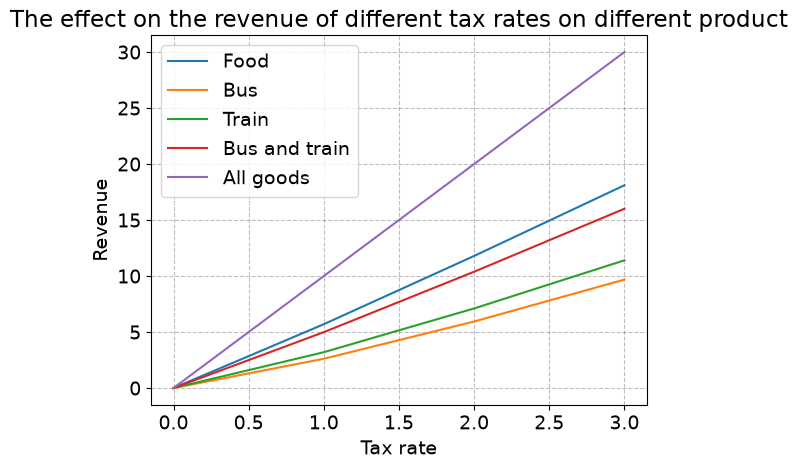

In [70]:
from Government import GovernmentClass

#Only food
food_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(1,))
    food_tax.append(x[0])

#only bus
bus_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(2,))
    bus_tax.append(x[0])

#Only train
train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(3,))
    train_tax.append(x[0])

#Bus and train tax
bus_and_train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(2,3))
    bus_and_train_tax.append(x[0])

#Tax on all goods
all_goods_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(1,2,3))
    all_goods_tax.append(x[0])

taxes = [0,1,2,3]

plt.plot(taxes, food_tax, label="Food")
plt.plot(taxes, bus_tax, label="Bus")
plt.plot(taxes, train_tax, label="Train")
plt.plot(taxes, bus_and_train_tax, label="Bus and train")
plt.plot(taxes, all_goods_tax, label="All goods")

plt.xlabel("Tax rate")
plt.ylabel("Revenue")
plt.title("The effect on the revenue of different tax rates on different product")

plt.legend(loc="upper left")  # Box
plt.grid(True)
plt.show()

### Calibration: Substitutes

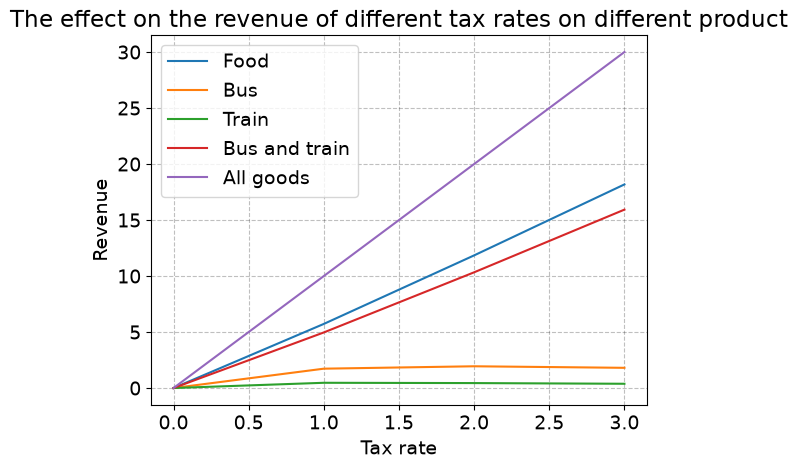

In [71]:
from Government import GovernmentClass
from Our_Consumer import ConsumerClass

#Changing sigma_B so train and bus are substitutes
model_subtitutes = GovernmentClass(par={"sigma_B":3.0})

#Only food
food_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(1,))
    food_tax.append(x[0])

#only bus
bus_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(2,))
    bus_tax.append(x[0])

#Only train
train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(3,))
    train_tax.append(x[0])

#Bus and train tax
bus_and_train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(2,3))
    bus_and_train_tax.append(x[0])

#Tax on all goods
all_goods_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(1,2,3))
    all_goods_tax.append(x[0])

taxes = [0,1,2,3]

plt.plot(taxes, food_tax, label="Food")
plt.plot(taxes, bus_tax, label="Bus")
plt.plot(taxes, train_tax, label="Train")
plt.plot(taxes, bus_and_train_tax, label="Bus and train")
plt.plot(taxes, all_goods_tax, label="All goods")

plt.xlabel("Tax rate")
plt.ylabel("Revenue")
plt.title("The effect on the revenue of different tax rates on different product")

plt.legend(loc="upper left")  # Box
plt.grid(True)
plt.show()


## 4.3

Which of the curves have a top and which just keep rising?


The curves which represent tax on the bus and tax on the train have a top in the case where bus and train are substitutes. The other curves are rising in the case with bus and train as substitutes. In the case where bus and train are complements all curves continues rising.

In [73]:
# The revenue-maximizing rate and the largest possible revenue where there is a top.
gor = GovernmentClass(par={"sigma_B":3.0})

#train_max = optimize.minimize(gor.revenue_and_utility(tau,(3,)), 0,method='L-BFGS-B', bounds=(0,3))

train_max = optimize.minimize_scalar(lambda tau: -gor.revenue_and_utility(tau, (3,))[0], bounds=(0, 3), method="bounded")

tau_optimal = train_max.x
max_revenue = -train_max.fun

print("Optimal tau:", tau_optimal)
print("Max revenue:", max_revenue)

print(train_max)

Optimal tau: 1.211601085618209
Max revenue: 0.47308802647981996
 message: Solution found.
 success: True
  status: 0
     fun: -0.47308802647981996
       x: 1.211601085618209
     nit: 21
    nfev: 21


As seen in the calculations above, the optimal tax on the train tickets is 1.212 which gives a revenue of 0.473

## 4.4

### Calibration: Complements

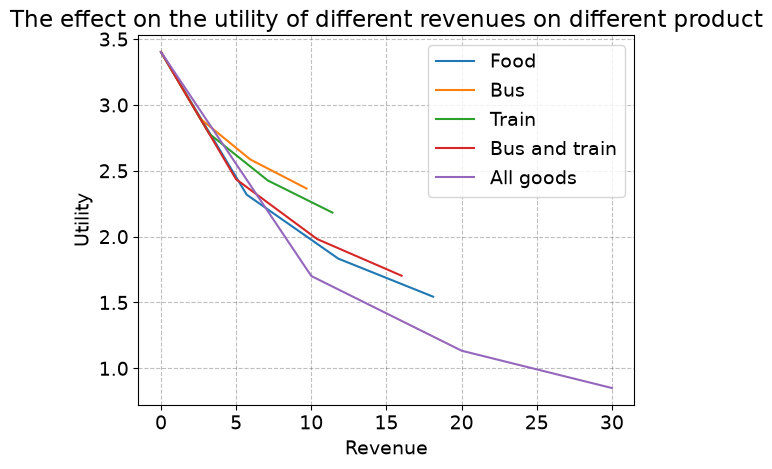

In [77]:
from Government import GovernmentClass

#Only food
food_rev = []
food_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R,u = gov.revenue_and_utility(tau,(1,))
    food_rev.append(R)
    food_util.append(u)

#only bus
bus_rev = []
bus_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(2,))
    bus_rev.append(R)
    bus_util.append(u)

#Only train
train_rev = []
train_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(3,))
    train_rev.append(R)
    train_util.append(u)

#Bus and train tax
bus_and_train_rev = []
bus_and_train_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(2,3))
    bus_and_train_rev.append(R)
    bus_and_train_util.append(u)

#Tax on all goods
all_goods_rev = []
all_goods_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(1,2,3))
    all_goods_rev.append(R)
    all_goods_util.append(u)

#Lump sump - missing!!!!


plt.plot(food_rev, food_util, label="Food")
plt.plot(bus_rev, bus_util, label="Bus")
plt.plot(train_rev, train_util, label="Train")
plt.plot(bus_and_train_rev, bus_and_train_util, label="Bus and train")
plt.plot(all_goods_rev, all_goods_util, label="All goods")

plt.xlabel("Revenue")
plt.ylabel("Utility")
plt.title("The effect on the utility of different revenues on different product")

plt.legend(loc="upper right")  # Box
plt.grid(True)
plt.show()